# Yield Curve Modeling, Bond Portfolio Risk, and Recession Forecasting using US Treasury Data

---

# Objective

Build a unified framework to:

1. Model and compare US Treasury yield curves using Nelson-Siegel and Cubic Spline methods.
2. Assess interest rate risk for a bond portfolio using DV01, duration, convexity, and Historical VaR.
3. Forecast the 10Y–2Y yield spread using time-series models (ARIMA, Holt-Winters).
4. Predict economic recessions using macro-financial indicators and machine learning.

---

# Methodology

## Yield Curve Fitting

- Used the most recent US Treasury yields (1M to 30Y).
- Fitted:
  - **Nelson-Siegel model** (parametric)
  - **Cubic Spline** (non-parametric)
- Compared out-of-sample prediction on the 7Y yield (excluded during fitting).

**RMSE Comparison:**
- Nelson-Siegel: `0.0909`
- Cubic Spline: `0.0451` 



## Bond Portfolio Risk

- Portfolio: 2Y, 10Y, 30Y coupon bonds with face value = 100.
- Calculated:
  - **DV01**: 1.43 per 1bp
  - **Duration**: 6.56 years
  - **Convexity**: 96.93
- Simulated daily PnL using actual historical yield changes (last 500 days).
- Computed **1-day 99% Historical VaR**: `18.44`

---

## Yield Spread Time Series Modeling

- Spread = 10Y - 2Y yield.
- Found spread is **non-stationary** but becomes stationary after first difference.
- Time series models:
  - ARIMA(3,1,0)
  - EWMA
  - Holt-Winters (additive trend)

**RMSE Comparison (Test Forecast, 30 periods):**
- ARIMA(3,1,0): `0.0237`
- Holt-Winters: `0.0235`
- EWMA: `0.0302`



## Recession Forecasting (with Cross Validation)

- Quarterly macro-financial data (1947–2023) with:
  - Features: `cpi`, `unemployment`, `fed_funds`, `gdp_lag1`, `ten_two_lag1`, `m2_lag1`, `residential`
  - Target: NBER recession indicator (binary)
- Used **Stratified 5-Fold Cross-Validation** with **SMOTE** to balance classes in each fold.
- Trained:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - K-Nearest Neighbors (KNN)
- Evaluated using: Accuracy, ROC AUC, Recall, Precision, F1 Score

## Cross-Validated Model Performance

| Model              | Accuracy | ROC AUC | Recall | Precision | F1 Score |
|-------------------|----------|---------|--------|-----------|----------|
| **Logistic Regression** | 0.88     | 0.88    | **0.84** | 0.54      | **0.64** |
| **Random Forest**       | **0.92** | **0.93**| 0.56   | **0.75**  | 0.63     |
| **XGBoost**             | 0.91     | 0.86    | 0.57   | 0.62      | 0.59     |
| **KNN**                 | 0.89     | 0.89    | 0.73   | 0.56      | 0.63     |


## Feature Importance Across Models

| Feature         | Logistic Coef | Random Forest | XGBoost | KNN (Perm.) |
|----------------|----------------|----------------|---------|-------------|
| **Residential**     | **-1.927**       | **0.359**        | **0.378** | **0.115**    |
| Ten_two_lag1    | -1.455           | 0.128          | 0.139    | 0.115       |
| M2_lag1         | -1.158           | 0.100          | 0.099    | 0.041       |
| GDP_lag1        | 1.326            | 0.078          | 0.077    | 0.033       |
| Fed_funds       | -0.489           | 0.145          | 0.077    | 0.012       |
| Unemployment    | 0.694            | 0.093          | 0.104    | 0.056       |
| CPI             | -0.344           | 0.098          | 0.125    | 0.034       |

---


# Key Findings

- **Cubic Spline** outperformed Nelson-Siegel in yield curve fitting (lower RMSE).
- The bond portfolio has moderate-to-high interest rate risk; VaR highlights downside tail exposure.
- Yield spread behaves like an I(1) process; ARIMA and Holt-Winters perform best for forecasting.
- **Residential investment** and **lagged yield curve slope** are consistently the most important recession predictors.
- Logistic Regression offered the **highest recall (0.84)**, making it valuable for early warning.
- Random Forest achieved the **highest accuracy (0.92)** and AUC (0.93), showing strong generalization.

---


# Conclusion

This project demonstrates an end-to-end quantitative approach to:

- Modeling the term structure of interest rates,
- Quantifying fixed income risk,
- Forecasting economic indicators using time series analysis, and
- Predicting recessions with machine learning under robust cross-validation.

It showcases the integration of financial theory, time series techniques, and modern supervised learning — applicable to roles in **quant research**, **risk management**, **macroeconomic forecasting**, and **policy modeling**.

---

# Code

Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR
import statsmodels.tsa.api as tsa
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm


from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier


from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

import os
import random
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


Collected US Treasury yield data across 11 maturities ranging from 1 month to 30 years, covering the period from 1962 to 2025.

In [2]:
yield_data = pd.read_csv("us_treasury_yields_1962-2025.csv", parse_dates=['date'], index_col='date')
yield_data = yield_data.sort_index()
yield_data.tail()

,US1M,US3M,US6M,US1Y,US2Y,US3Y,US5Y,US7Y,US10Y,US20Y,US30Y
date,,,,,,,,,,,
2025-06-09,4.29,4.44,4.32,4.13,4.01,3.99,4.09,4.28,4.49,4.98,4.95
2025-06-10,4.29,4.45,4.32,4.12,4.01,3.95,4.08,4.27,4.47,4.96,4.93
2025-06-11,4.30,4.45,4.31,4.08,3.94,3.89,4.02,4.21,4.41,4.93,4.91
2025-06-12,4.18,4.46,4.29,4.06,3.90,3.85,3.97,4.15,4.36,4.86,4.84
2025-06-13,4.23,4.45,4.30,4.09,3.96,3.90,4.02,4.20,4.41,4.93,4.90


In [3]:
print(yield_data.info())
print(yield_data.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16543 entries, 1962-01-02 to 2025-06-13
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   US1M    5970 non-null   float64
 1   US3M    10946 non-null  float64
 2   US6M    10946 non-null  float64
 3   US1Y    15848 non-null  float64
 4   US2Y    12256 non-null  float64
 5   US3Y    15848 non-null  float64
 6   US5Y    15848 non-null  float64
 7   US7Y    13978 non-null  float64
 8   US10Y   15848 non-null  float64
 9   US20Y   14159 non-null  float64
 10  US30Y   12078 non-null  float64
dtypes: float64(11)
memory usage: 1.5 MB
None
              US1M          US3M          US6M          US1Y          US2Y  \
count  5970.000000  10946.000000  10946.000000  15848.000000  12256.000000   
mean      1.605764      3.825985      3.996116      4.893701      4.981844   
std       1.813973      3.153469      3.256073      3.374855      3.693891   
min       0.000000      0.000000   

In [4]:
yield_changes = yield_data.diff().dropna()

Fitting Nelson Siegel model

In [5]:
observed_yields = yield_data.iloc[-1]
maturities = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])

In [6]:
def nelson_siegel(tau, beta0, beta1, beta2, lambd):
    term1 = (1 - np.exp(-lambd * tau)) / (lambd * tau)
    term2 = term1 - np.exp(-lambd * tau)
    return beta0 + beta1 * term1 + beta2 * term2

initial_guess = [4.0, -2.0, 2.0, 0.5]  # [beta0, beta1, beta2, lambda]
bounds = ([0, -5, -5, 0.01], [10, 5, 5, 5])

fitted_params, _ = curve_fit(
    nelson_siegel,
    maturities,
    observed_yields,
    p0=initial_guess,
    bounds=bounds,
    maxfev=10000  # allow more function evaluations
)

# Predicted yields
fitted_yields = nelson_siegel(maturities, *fitted_params)
# Output fitted parameters
param_names = ['beta0', 'beta1', 'beta2', 'lambda']
for name, value in zip(param_names, fitted_params):
    print(f"{name} = {value:.5f}")

beta0 = 5.29227
beta1 = -0.86770
beta2 = -3.03552
lambda = 0.41831


Cubic spline fit

In [7]:
# Fit cubic spline
cs = CubicSpline(maturities, observed_yields, bc_type='natural') 
x_fine = np.linspace(min(maturities), max(maturities), 500)
y_fine = cs(x_fine)

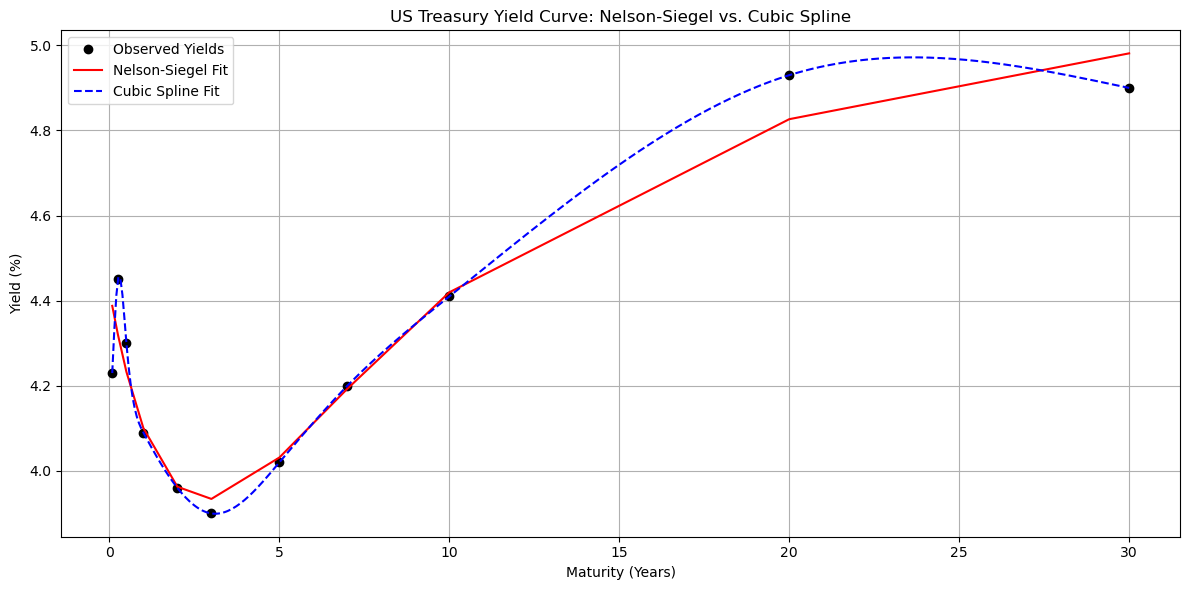

In [8]:

plt.figure(figsize=(12, 6))
plt.plot(maturities, observed_yields, 'o', color='black', label='Observed Yields')
plt.plot(maturities, fitted_yields, 'r-', label='Nelson-Siegel Fit')
plt.plot(x_fine, y_fine, 'b--', label='Cubic Spline Fit')

plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.title('US Treasury Yield Curve: Nelson-Siegel vs. Cubic Spline')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The 7-year maturity yield was excluded from the dataset to serve as a test point. Nelson-Siegel and cubic spline models were fitted to the remaining maturities, and their out-of-sample performance was evaluated using RMSE to determine the better-fitting model.

In [9]:
clean_yield_data = yield_data.dropna()
n_total = len(clean_yield_data)


ns_errors = []
spline_errors = []

train_maturities = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 10, 20, 30])

for i in range(n_total):  # or sample some subset
    X_observed_yields = clean_yield_data.drop(columns=["US7Y"]).iloc[i]
    y_observed_yields = clean_yield_data.iloc[i,7]
    
    
    # ----- Nelson-Siegel -----

    fitted_params_train, _ = curve_fit(nelson_siegel, train_maturities, X_observed_yields, p0=initial_guess, bounds=bounds, maxfev=10000)
    fitted_yields_train = nelson_siegel(train_maturities, *fitted_params)
    
    pred_7y_ns = nelson_siegel(7, *fitted_params_train)
    ns_errors.append((pred_7y_ns - y_observed_yields)**2)
    
    # ----- Cubic Spline -----
    cs = CubicSpline(train_maturities, X_observed_yields, bc_type='natural')
    pred_7y_spline = cs(7)
    spline_errors.append((pred_7y_spline - y_observed_yields)**2)


rmse_ns = np.sqrt(np.mean(ns_errors))
rmse_spline = np.sqrt(np.mean(spline_errors))

print(f"RMSE Nelson-Siegel: {rmse_ns:.5f}")
print(f"RMSE Cubic Spline: {rmse_spline:.5f}")


RMSE Nelson-Siegel: 0.09089
RMSE Cubic Spline: 0.04514


# Bond portfolio and risk

In [10]:
def bond_price(face, coupon, maturity, ytm, freq=2):
    periods = int(maturity * freq)
    coupon_payment = (coupon / 100) * face / freq
    discount_factors = [(1 + ytm / freq) ** (-i) for i in range(1, periods + 1)]
    price = sum(coupon_payment * dfactors for dfactors in discount_factors)
    price += face * discount_factors[-1]
    return price

In [11]:
# A hypothetical bond portfolio
portfolio = {
    '2 Yr': {'maturity': 2, 'ytm': 0.045, 'coupon': 5.0, 'face': 100, 'quantity': 10},
    '10 Yr': {'maturity': 10, 'ytm': 0.05, 'coupon': 5.0, 'face': 100, 'quantity': 7},
    '30 Yr': {'maturity': 30, 'ytm': 0.055, 'coupon': 5.0, 'face': 100, 'quantity': 5},
}
bond_tenors = list(portfolio.keys())  # ['2 Yr', '10 Yr', '30 Yr']

Compute price, DV01, duration, convexity

In [12]:
def compute_risk_metrics(bond, freq=2):
    ytm = bond['ytm']
    maturity = bond['maturity']
    coupon = bond['coupon']
    face = bond['face']

    price = bond_price(face, coupon, maturity, ytm, freq)
    bump = 0.0001  # 1 basis point

    price_up = bond_price(face, coupon, maturity, ytm + bump, freq)
    price_down = bond_price(face, coupon, maturity, ytm - bump, freq)

    dv01 = (price_down - price_up) / 2
    duration = - (price_down - price_up) / (2 * price * bump)
    convexity = (price_up + price_down - 2 * price) / (price * bump**2)

    return price, dv01, duration, convexity


In [13]:
portfolio_metrics = {}
total_value = 0
for name, bond in portfolio.items():
    price, dv01, duration, convexity = compute_risk_metrics(bond)
    value = price * bond['quantity']
    total_value += value

    portfolio_metrics[name] = {
        'price': price,
        'value': value,
        'dv01': dv01 * bond['quantity'],
        'duration': duration,
        'convexity': convexity
    }




In [14]:
portfolio_dv01 = sum(b['dv01'] for b in portfolio_metrics.values())
portfolio_duration = sum((b['value'] / total_value) * b['duration'] for b in portfolio_metrics.values())
portfolio_convexity = sum((b['value'] / total_value) * b['convexity'] for b in portfolio_metrics.values())


print(f"Portfolio DV01: {portfolio_dv01:.2f} per 1 bp")
print(f"Portfolio Duration: {-1*portfolio_duration:.2f} years")
print(f"Portfolio Convexity: {portfolio_convexity:.2f}")

Portfolio DV01: 1.43 per 1 bp
Portfolio Duration: 6.56 years
Portfolio Convexity: 96.93


Portfolio VaR over last 500 days

In [15]:
daily_pnl = []
for i in range(500):
    shock = yield_changes.tail(500).iloc[i]

    pnl = 0
    for name, bond in portfolio.items():
        bump = shock["US"+name.split()[0]+"Y"]  # yield shock for this tenor
        original_price = bond_price(bond['face'], bond['coupon'], bond['maturity'], bond['ytm'])
        shocked_price = bond_price(bond['face'], bond['coupon'], bond['maturity'], bond['ytm'] + bump / 100)
        pnl += (shocked_price - original_price) * bond['quantity']
    daily_pnl.append(pnl)


VaR_99 = -np.percentile(daily_pnl, 1)
print(f"Historical 1-day 99% VaR: {VaR_99:.2f}")


Historical 1-day 99% VaR: 18.44


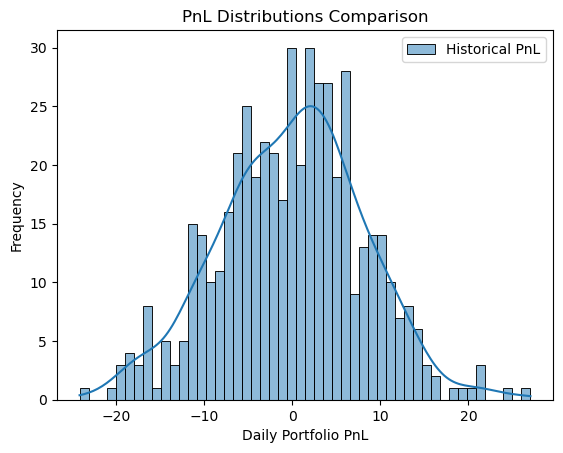

In [16]:
sns.histplot(daily_pnl, bins=50, kde=True, label='Historical PnL')
#sns.histplot(simulated_pnl, bins=50, kde=True, label='Simulated PnL (PCA)')
plt.legend()
plt.title('PnL Distributions Comparison')
plt.xlabel('Daily Portfolio PnL')
plt.ylabel('Frequency')
plt.show()


# Time Series Modelling of Spread (10Y yield - 2Y yield) 

In [17]:
spread_10y_2y = yield_data["US10Y"] - yield_data["US2Y"]
spread_10y_2y.dropna(inplace=True)
spread = spread_10y_2y.copy()
spread = spread.squeeze()  # convert to Series if it's a single column DataFrame
spread = spread.asfreq('B')  # ensure business day frequency
spread = spread.interpolate(method='time')

In [18]:
print(spread.describe())

count    12794.000000
mean         0.852860
std          0.922752
min         -2.410000
25%          0.180000
50%          0.810000
75%          1.490000
max          2.910000
dtype: float64


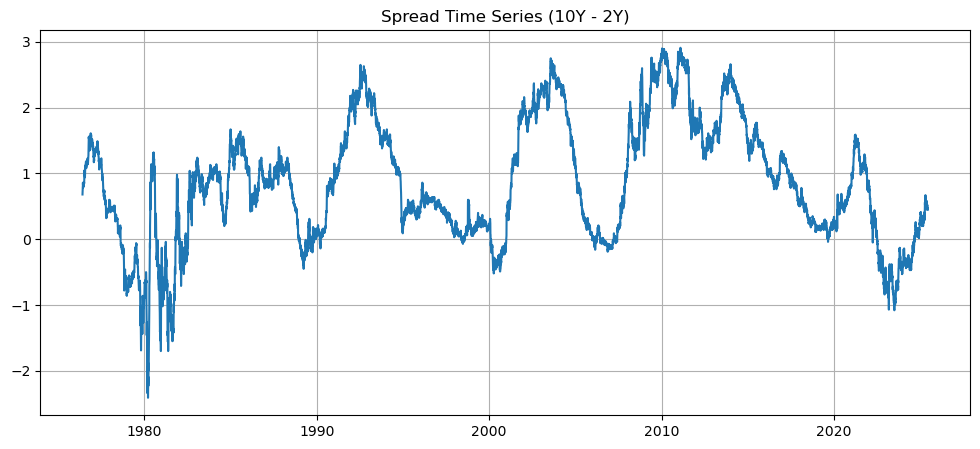

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(spread)
plt.title("Spread Time Series (10Y - 2Y)")
plt.grid(True)
plt.show()

Stationarity check

In [20]:
def adf_test(timeseries):
    print("Results of ADF test:")
    result = adfuller(timeseries.dropna())
    print(f"ADF Statistic: {result[0]:.3f}")
    print(f"p-value: {result[1]:.3f}")
    if result[1]<0.05:
        print("Data is likely staionary")
    else:
        print("Data is likely non-staionary")    

def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"])
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)
    if kpsstest[1] > 0.05:
        print("Data is likely stationary")
    else:
        print("Data is likely non-stationary")


In [21]:
adf_test(spread)
kpss_test(spread)

Results of ADF test:
ADF Statistic: -3.142
p-value: 0.024
Data is likely staionary
Results of KPSS Test:
Test Statistic            1.506918
p-value                   0.010000
Lags Used                70.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
Data is likely non-stationary


In [22]:
spread_diff = spread.diff().dropna()
adf_test(spread_diff)
kpss_test(spread_diff)

Results of ADF test:
ADF Statistic: -19.278
p-value: 0.000
Data is likely staionary
Results of KPSS Test:
Test Statistic            0.031525
p-value                   0.100000
Lags Used                19.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
Data is likely stationary


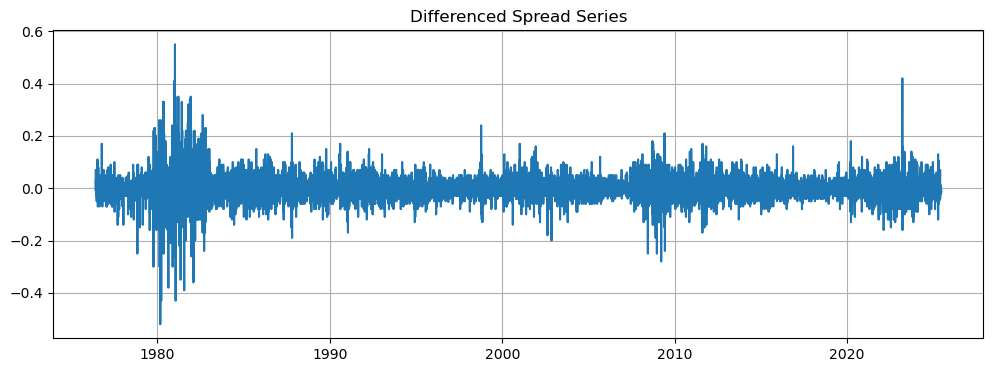

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(spread_diff)
plt.title("Differenced Spread Series")
plt.grid(True)
plt.show()

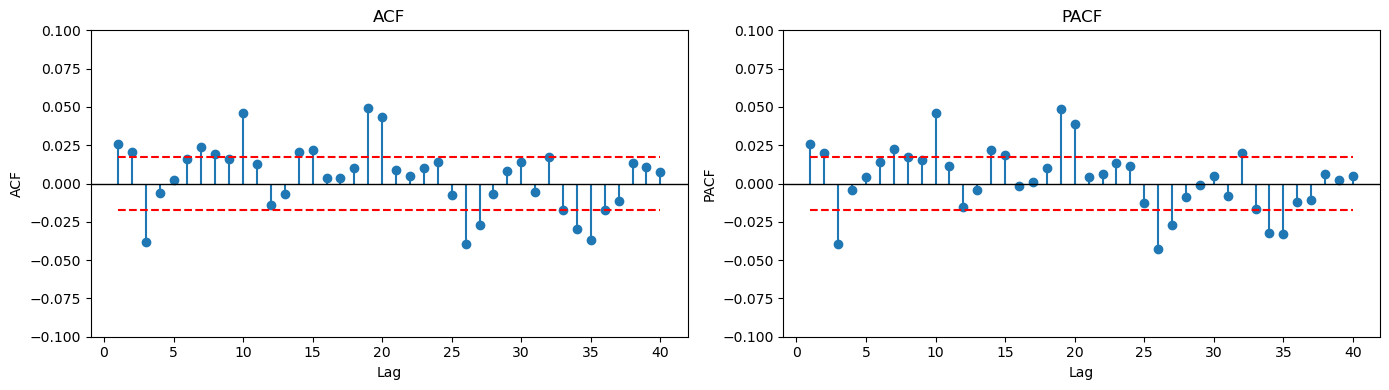

In [24]:
series = spread_diff

lags = 40
acf_vals = acf(series, nlags=lags)
pacf_vals = pacf(series, nlags=lags, method='ywm')

# Remove lag 0
acf_vals = acf_vals[1:]
pacf_vals = pacf_vals[1:]
lags_range = np.arange(1, lags + 1)

# Compute 95% confidence bounds
conf_level = 1.96 / np.sqrt(len(series))

# Plot
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# ACF plot
axs[0].stem(lags_range, acf_vals, basefmt=" ")
axs[0].hlines([conf_level, -conf_level], xmin=1, xmax=lags, linestyles='dashed', colors='red')
axs[0].axhline(0, color='black', linewidth=1)
axs[0].set_title("ACF")
axs[0].set_xlabel("Lag")
axs[0].set_ylabel("ACF")
axs[0].set_ylim(-0.1, 0.1) 

# PACF plot
axs[1].stem(lags_range, pacf_vals, basefmt=" ")
axs[1].hlines([conf_level, -conf_level], xmin=1, xmax=lags, linestyles='dashed', colors='red')
axs[1].axhline(0, color='black', linewidth=1)
axs[1].set_title("PACF")
axs[1].set_xlabel("Lag")
axs[1].set_ylabel("PACF")
axs[1].set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.savefig("acf-pacf.png")
plt.show()


- ACF:
  - Significant spikes at lags 1, 2, 3, 7, 10, 19, 20 and slow decay afterward
  - This suggests the possibility of MA terms, likely q = 1, 2, 3.

- PACF:
  - Significant spikes at lags 1, 2, 3, 7, 10, 19, 20, 25
  - Suggests presence of AR terms, possibly p = 1, 2, 3.

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-43154.418, Time=1.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-43160.787, Time=0.78 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-43160.416, Time=0.85 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-43156.416, Time=0.54 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-43164.027, Time=0.97 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-43181.807, Time=1.13 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-43180.060, Time=1.41 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-43179.745, Time=1.27 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-43162.292, Time=3.28 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-43178.062, Time=1.91 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-43183.805, Time=0.73 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-43166.025, Time=0.48 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=-43182.058, Time=0.90 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=-43181.743, Time=0.83 sec
 ARIM

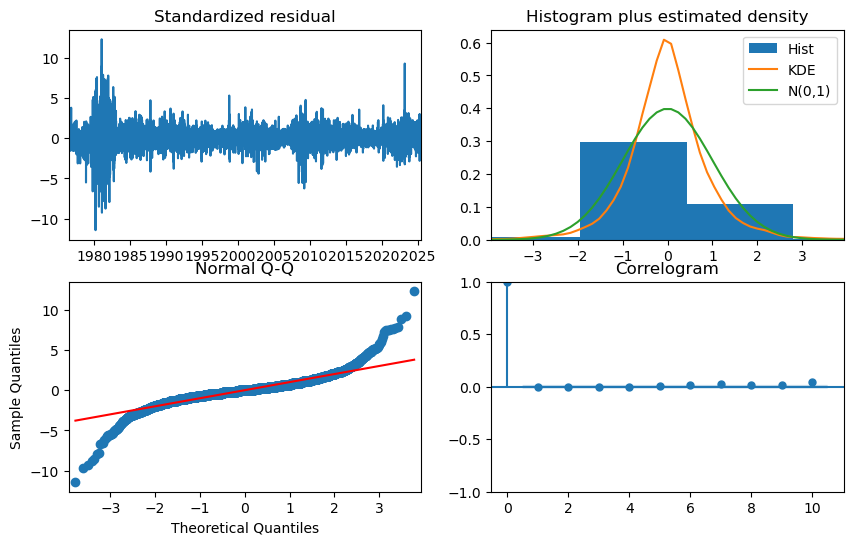

In [25]:

auto_model = pm.auto_arima(spread, 
                           start_p=0, start_q=0,
                           max_p=5, max_q=5,
                           d=1,          
                           seasonal=False,
                           stepwise=True, # faster search
                           suppress_warnings=True,
                           error_action='ignore',
                           trace=True)

# Summary of the best model
print(auto_model.summary())

# Plot diagnostics
auto_model.plot_diagnostics(figsize=(10, 6))
plt.show()


In [26]:

# ----- Train-test split -----
test_size = 30
train = spread.iloc[:-test_size]
test = spread.iloc[-test_size:]

# ----- Rolling Forecast -----
arima_forecast= []
ewma_forecast = []
es_forecast = []
actual_values = []

for i in range(test_size):
    train_window = spread.iloc[:-(test_size - i)]
    
    # ARIMA(3,1,0)
    model= ARIMA(train_window, order=(3,1,0))
    model_fit = model.fit()
    arima_pred = model_fit.forecast()[0]
    arima_forecast.append(arima_pred)


    # EWMA
    ewma_pred = train_window.ewm(span=20).mean().iloc[-1]
    ewma_forecast.append(ewma_pred)

    model_es = ExponentialSmoothing(train_window, trend="add", seasonal=None)
    model_fit_es = model_es.fit()
    
    es_pred = model_fit_es.forecast(steps=1)[0]
    es_forecast.append(es_pred)
    
    
    

    # Actual value
    actual_values.append(test.iloc[i])

# ----- Compute RMSE -----
rmse_arima = np.sqrt(mean_squared_error(actual_values, arima_forecast))
rmse_ewma = np.sqrt(mean_squared_error(actual_values, ewma_forecast))
rmse_es = np.sqrt(mean_squared_error(actual_values, es_forecast))


In [27]:
print(f"ARIMA(3,1,0) RMSE: {rmse_arima:.4f}")
print(f"EWMA RMSE:        {rmse_ewma:.4f}")
print(f"Holt Winter RMSE: {rmse_es:.4f}")

ARIMA(3,1,0) RMSE: 0.0237
EWMA RMSE:        0.0302
Holt Winter RMSE: 0.0235


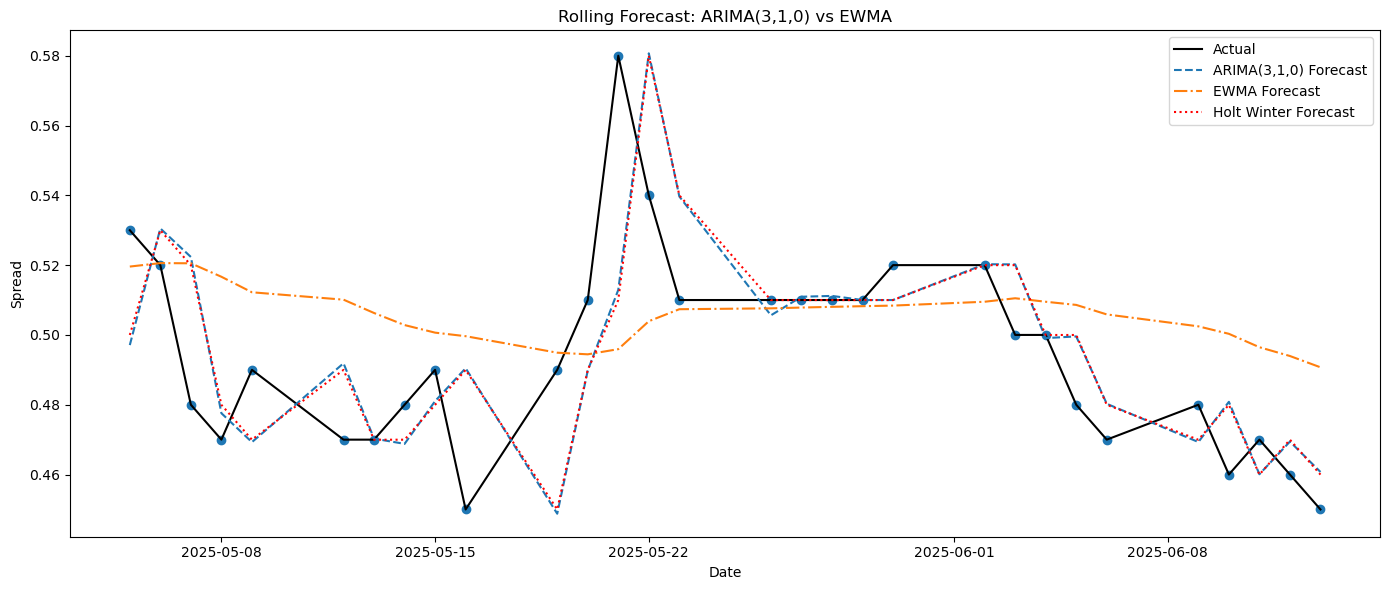

In [28]:

# ----- Plot the forecast vs actual -----
plt.figure(figsize=(14,6))
plt.scatter(test.index, actual_values)
plt.plot(test.index, actual_values, label='Actual', color='black')
plt.plot(test.index, arima_forecast, label='ARIMA(3,1,0) Forecast', linestyle='--')
plt.plot(test.index, ewma_forecast, label='EWMA Forecast', linestyle='-.')
plt.plot(test.index, es_forecast, label='Holt Winter Forecast', linestyle=':', color="red")
plt.title('Rolling Forecast: ARIMA(3,1,0) vs EWMA')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.legend()
plt.tight_layout()
plt.show()

# Recession forecasting

Collected the data from https://www.kaggle.com/datasets/xkevnx/us-economic-data/data

In [29]:
recession_df = pd.read_csv("fredmeta.csv", parse_dates=['date'], index_col='date')
recession_df.tail()

,recession,cpi,gdp,unemployment,m2,fed_funds,ten_two,residential
date,,,,,,,,
2023-08-01,0,307.026,NaN,3.9,20721.3,5.33,-0.73,NaN
2023-09-01,0,307.789,NaN,3.6,20699.8,5.33,-0.64,NaN
2023-10-01,0,307.671,22672.859,3.6,20671.2,5.33,-0.27,NaN
2023-11-01,0,307.051,NaN,3.5,20760.4,5.33,-0.38,NaN
2023-12-01,0,306.746,NaN,3.5,20929.0,5.33,-0.44,NaN


In [30]:
print(recession_df.info())
print(recession_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 924 entries, 1947-01-01 to 2023-12-01
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recession     924 non-null    int64  
 1   cpi           924 non-null    float64
 2   gdp           308 non-null    float64
 3   unemployment  912 non-null    float64
 4   m2            780 non-null    float64
 5   fed_funds     834 non-null    float64
 6   ten_two       571 non-null    float64
 7   residential   211 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 65.0 KB
None
        recession         cpi           gdp  unemployment            m2  \
count  924.000000  924.000000    308.000000    912.000000    780.000000   
mean     0.134199  119.018950   9968.205994      5.705044   5186.605000   
std      0.341051   84.845533   6050.916310      1.751279   5471.275168   
min      0.000000   21.500000   2172.432000      2.400000    287.700000   
25%      0.00000

In [31]:
recession_dfq = recession_df.resample('Q').agg({
    'recession': 'max', 
    'cpi': 'mean',
    'gdp': 'mean',
    'unemployment': 'mean',
    'm2': 'mean',
    'fed_funds': 'mean',
    'ten_two': 'mean',
    'residential': 'mean'
})


In [32]:
first_valid_index = recession_dfq.dropna().index[0]
recession_dfq[first_valid_index:].isnull().sum()

recession       0
cpi             0
gdp             0
unemployment    0
m2              0
fed_funds       0
ten_two         0
residential     1
dtype: int64

In [33]:
recession_dfq = recession_dfq[first_valid_index:].copy()

In [34]:
recession_dfq.ffill(inplace=True)
recession_dfq.isnull().any()

recession       False
cpi             False
gdp             False
unemployment    False
m2              False
fed_funds       False
ten_two         False
residential     False
dtype: bool

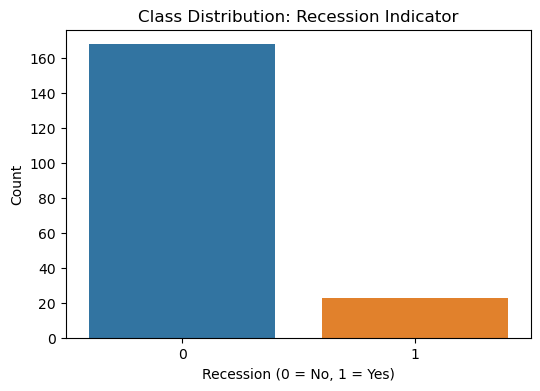

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x="recession", data=recession_dfq)
plt.title("Class Distribution: Recession Indicator")
plt.xlabel("Recession (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [36]:
imbalance_ratio = recession_dfq["recession"].sum() / (len(recession_dfq)-recession_dfq["recession"].sum())
print(f"The ratio of YES (recession = 1) to NO (recession = 0) is {imbalance_ratio *100 : .2f}%")

The ratio of YES (recession = 1) to NO (recession = 0) is  13.69%


Addressed class imbalance with SMOTE oversampling.

In [37]:
# Create lagged features
recession_dfq['gdp_lag1'] = recession_dfq['gdp'].shift(1)
recession_dfq['ten_two_lag1'] = recession_dfq['ten_two'].shift(1)
recession_dfq['m2_lag1'] = recession_dfq['m2'].shift(1)

# Drop rows with NaNs
recession_dfq = recession_dfq.dropna()





In [38]:
# Define features and target
X = recession_dfq[['cpi', 'unemployment', 'fed_funds', 'gdp_lag1', 'ten_two_lag1', 'm2_lag1', 'residential']]
y = recession_dfq['recession']
feature_names = X.columns

# Define models
models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42, bootstrap=True),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, nthread=1, tree_method='exact', deterministic=True),
    'KNN': KNeighborsClassifier()
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Results storage
model_scores = {name: [] for name in models}
feature_importances = {name: pd.Series(0, index=feature_names) for name in models}

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Apply SMOTE only on training data
        smote = SMOTE(random_state=42)
        X_res, y_res = smote.fit_resample(X_train, y_train)

        # Pipeline
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])
        
        pipe.fit(X_res, y_res)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        f1 = f1_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)

        model_scores[name].append({
            'accuracy': acc, 'auc': auc, 'f1': f1,
            'recall': recall, 'precision': precision
        })

        # Feature importance
        clf = pipe.named_steps['clf']
        if name == 'LogisticRegression':
            coefs = clf.coef_[0]
            feature_importances[name] += pd.Series(coefs, index=feature_names)

        elif name in ['RandomForest', 'XGBoost']:
            importances = clf.feature_importances_
            feature_importances[name] += pd.Series(importances, index=feature_names)

        elif name == 'KNN':
            result = permutation_importance(pipe, X_test, y_test, n_repeats=5, random_state=42)
            importances = result.importances_mean
            feature_importances[name] += pd.Series(importances, index=feature_names)

    # Average feature importance over folds
    feature_importances[name] /= cv.get_n_splits()

    # Print average metrics
    avg_scores = pd.DataFrame(model_scores[name]).mean()
    print(f"Avg Accuracy: {avg_scores['accuracy']:.2f}")
    print(f"Avg ROC AUC: {avg_scores['auc']:.2f}")
    print(f"Avg F1 Score: {avg_scores['f1']:.2f}")
    print(f"Avg Recall: {avg_scores['recall']:.2f}")
    print(f"Avg Precision: {avg_scores['precision']:.2f}")

# Final Feature Importance Table
importance_df = pd.DataFrame(feature_importances)
importance_df = importance_df.loc[:, importance_df.columns.intersection(models.keys())]
print("\nFeature Importance Comparison Table:")
print(importance_df.round(3))


=== LogisticRegression ===
Avg Accuracy: 0.88
Avg ROC AUC: 0.88
Avg F1 Score: 0.64
Avg Recall: 0.84
Avg Precision: 0.54

=== RandomForest ===
Avg Accuracy: 0.92
Avg ROC AUC: 0.93
Avg F1 Score: 0.63
Avg Recall: 0.56
Avg Precision: 0.75

=== XGBoost ===
Avg Accuracy: 0.91
Avg ROC AUC: 0.86
Avg F1 Score: 0.59
Avg Recall: 0.57
Avg Precision: 0.62

=== KNN ===
Avg Accuracy: 0.89
Avg ROC AUC: 0.89
Avg F1 Score: 0.63
Avg Recall: 0.73
Avg Precision: 0.56

Feature Importance Comparison Table:
              LogisticRegression  RandomForest  XGBoost    KNN
cpi                       -0.344         0.098    0.125  0.034
unemployment               0.694         0.093    0.104  0.056
fed_funds                 -0.489         0.145    0.077  0.012
gdp_lag1                   1.326         0.078    0.077  0.033
ten_two_lag1              -1.455         0.128    0.139  0.115
m2_lag1                   -1.158         0.100    0.099  0.041
residential               -1.927         0.359    0.378  0.115


*ML models comparison*
  
1. Best overall recall: Logistic regression
2. Best AUC: Random Forest
3. Best F1 score: Logistic regression
4. Most balanced: Logistic Regression


*Feature Interpretation:*

1. Residential investment is consistently the most important predictor across all models.
2. Yield curve spread (10Y–2Y lag) is the next strongest recession indicator.
3. Logistic Regression highlights the negative impact of these variables on recession probability.
4. GDP lagged is more important in logistic but less so in tree-based models.
